# S2_gen_data_optimized_cp_v6

This notebook is a new bounded-parameter version of the Study 2 simulator.

## Design goal

Use psychologically constrained DDM parameter ranges based on your current assumptions:

- drift rate `v`: `0.05` to `0.40`
- boundary separation `a`: `0.10` to `0.30`

and keep a full runnable workflow with:

- generation
- original vs optimized comparison
- plots
- fast-RT diagnostics
- parameter summaries for later refinement

## Key modeling idea in v5

We define a continuous **task ease score** from `P`, `T`, and `W`.

- lower ease -> harder task -> lower `v`
- higher ease -> easier task -> higher `v`
- `W` and task difficulty jointly affect `a`
- anticipatory responses (`RT < 0.25s`) are flagged and excluded from the analysis dataset

This version is meant as a bounded trial model for error-checking and iteration, not as a final theory-locked model.
## v6 focus

This version keeps the v5 bounded RT-friendly structure, but strengthens the fixed self/stranger drift separation while still keeping `v` within `[0.05, 0.40]`.


## Parameter assumptions used here

### Drift rate `v`

You provided the following target intuition:

- global range: `0.05-0.40`
- difficult tasks: about `0.05-0.20`
- simple tasks: about `0.20-0.40`

So in this notebook we map the PTW-derived ease score to `v` **piecewise**:

- ease `< 0.5` -> difficult regime -> `v in [0.05, 0.20]`
- ease `>= 0.5` -> simple regime -> `v in [0.20, 0.40]`

This means the current **critical point** is defined at:

- `ease_score = 0.50`
- equivalently: this is the boundary between the difficult and simple drift regimes

### Boundary separation `a`

You provided an expected range of `0.10-0.30`.

In this notebook:

- higher `W` -> higher `a`
- harder tasks -> slightly higher `a`
- `a` is clipped to `[0.10, 0.30]`

### Non-decision time `t0`

To reduce the unrealistic pile-up near `0.20-0.25s`, this version uses a **subject-level `t0` distribution** rather than a fixed single value.

### Fast-response handling

This notebook explicitly marks:

- timeout trials
n- anticipatory trials (`RT < 0.25s`)

and creates a **valid analysis dataset** that excludes them.
### v6 change in condition effect

In v6, self/stranger separation is still treated as a fixed attentional-priority effect rather than a PTW-dependent effect. The difference is implemented as a stronger constant bonus/penalty on top of the same bounded `v_base`.


In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from joblib import Parallel, delayed

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('Matplotlib:', plt.matplotlib.__version__)

Python: 3.13.1
NumPy: 2.2.0
Pandas: 2.2.3
Matplotlib: 3.10.0


In [2]:
PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path(r'D:/GitHub_programe/GitHub/Guassion-Process-Experiment-Design'),
]

BASE_DIR = None
for candidate in PROJECT_ROOT_CANDIDATES:
    if (candidate / '1_Code').exists():
        BASE_DIR = candidate
        break

if BASE_DIR is None:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / '2_Data' / 'Generate_Data' / 'S2_gen_data_optimized_cp_v5'
FIG_DIR = BASE_DIR / '3_Figures' / 'S2_gen_data_optimized_cp_v5'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('BASE_DIR:', BASE_DIR)
print('DATA_DIR:', DATA_DIR)
print('FIG_DIR:', FIG_DIR)

BASE_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design
DATA_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\S2_gen_data_optimized_cp_v5
FIG_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\S2_gen_data_optimized_cp_v5


In [3]:
CONFIG = {
    'SEED': 42,
    'RUN_BENCHMARK': True,
    'RUN_VALIDATION_PLOTS': True,
    'RUN_LARGE_DATASET': False,
    'BENCHMARK_SUBJECTS': 1000,
    'BENCHMARK_TRIALS': 260,
    'NUM_SUBJECTS_LARGE': 3000,
    'NUM_TRIALS_LARGE': 260,
    'MIN_VALID_RT': 0.25,
    'MAX_DT': 0.001,
    'T0_MEAN': 0.28,
    'T0_SD': 0.02,
    'T0_MIN': 0.24,
    'T0_MAX': 0.35,
    'TRIAL_V_SD': 0.04,
    'A_CV': 0.08,
    'EASE_WEIGHTS': {'P': 0.35, 'T': 0.40, 'W': 0.25},
    'V_MIN': 0.05,
    'V_SPLIT': 0.20,
    'V_MAX': 0.40,
    'A_MIN': 0.10,
    'A_MAX': 0.30,
    'SELF_V_BONUS': 0.08,
    'STRANGER_V_PENALTY': 0.05,
}

SEED = CONFIG['SEED']
np.random.seed(SEED)

In [4]:
def normalize_ptw(P, T, W):
    Pn = np.clip((np.asarray(P, dtype=float) - 0.0) / 149.0, 0.0, 1.0)
    Tn = np.clip((np.asarray(T, dtype=float) - 10.0) / 589.0, 0.0, 1.0)
    Wn = np.clip((np.asarray(W, dtype=float) - 200.0) / 1299.0, 0.0, 1.0)
    return Pn, Tn, Wn


def compute_task_ease(P, T, W, cfg=CONFIG):
    Pn, Tn, Wn = normalize_ptw(P, T, W)
    w = cfg['EASE_WEIGHTS']
    ease = w['P'] * Pn + w['T'] * Tn + w['W'] * Wn
    return np.clip(ease, 0.0, 1.0)


def compute_v_base(P, T, W, cfg=CONFIG):
    ease = compute_task_ease(P, T, W, cfg=cfg)
    v = np.empty_like(np.asarray(ease, dtype=float))

    lower_mask = ease < 0.5
    upper_mask = ~lower_mask

    # Difficult regime: 0.05 -> 0.20
    v[lower_mask] = cfg['V_MIN'] + (cfg['V_SPLIT'] - cfg['V_MIN']) * (ease[lower_mask] / 0.5)

    # Simple regime: 0.20 -> 0.40
    v[upper_mask] = cfg['V_SPLIT'] + (cfg['V_MAX'] - cfg['V_SPLIT']) * ((ease[upper_mask] - 0.5) / 0.5)
    return np.clip(v, cfg['V_MIN'], cfg['V_MAX'])


def compute_v(P, T, W, condition_key, cfg=CONFIG):
    v_base = compute_v_base(P, T, W, cfg=cfg)
    condition_key = np.asarray(condition_key)
    bonus = np.where(condition_key == 1, cfg['SELF_V_BONUS'], -cfg['STRANGER_V_PENALTY'])
    v = v_base + bonus
    return np.clip(v, cfg['V_MIN'], cfg['V_MAX'])


def compute_a(P, T, W, cfg=CONFIG):
    ease = compute_task_ease(P, T, W, cfg=cfg)
    _, _, Wn = normalize_ptw(P, T, W)

    # Longer response windows allow slightly larger boundaries.
    # Harder tasks also receive somewhat larger boundaries.
    a = 0.12 + 0.10 * Wn + 0.05 * (1.0 - ease)
    return np.clip(a, cfg['A_MIN'], cfg['A_MAX'])


def sample_subject_t0(n_subjects, rng, cfg=CONFIG):
    t0 = rng.normal(cfg['T0_MEAN'], cfg['T0_SD'], size=n_subjects)
    return np.clip(t0, cfg['T0_MIN'], cfg['T0_MAX'])

In [5]:
def simulate_single_trial_vectorized(v, a, t0, max_time_steps, delta_t, rng):
    noise = rng.normal(loc=0.0, scale=np.sqrt(delta_t), size=max_time_steps)
    drift = v * delta_t
    evidence = a / 2.0 + np.cumsum(drift + noise)

    upper_crossing = np.where(evidence >= a)[0]
    lower_crossing = np.where(evidence <= 0)[0]

    if len(upper_crossing) > 0 and len(lower_crossing) > 0:
        if upper_crossing[0] < lower_crossing[0]:
            return (upper_crossing[0] + 1) * delta_t + t0, 1
        return (lower_crossing[0] + 1) * delta_t + t0, 2
    if len(upper_crossing) > 0:
        return (upper_crossing[0] + 1) * delta_t + t0, 1
    if len(lower_crossing) > 0:
        return (lower_crossing[0] + 1) * delta_t + t0, 2
    return max_time_steps * delta_t + t0, 0

In [6]:
def annotate_trial_validity(df, cfg=CONFIG):
    df = df.copy()
    df['is_timeout'] = df['response'] == 0
    df['is_fast_rt'] = df['RT'] < cfg['MIN_VALID_RT']
    df['is_valid'] = (~df['is_timeout']) & (~df['is_fast_rt']) & (df['RT'] < df['max_time'])
    return df


def extract_valid_trials(df):
    return df[df['is_valid']].copy()

In [7]:
def generate_data_random_params(num_subjects, num_trials, seed=SEED, cfg=CONFIG):
    rng = np.random.default_rng(seed)
    rows = []

    t0_subject = sample_subject_t0(num_subjects, rng, cfg=cfg)

    for subject in range(num_subjects):
        T = rng.integers(10, 600)
        P = rng.integers(0, 150)
        W = rng.integers(200, 1500)

        a_base = float(compute_a(P, T, W, cfg=cfg))
        a = float(np.clip(rng.normal(a_base, a_base * cfg['A_CV']), cfg['A_MIN'], cfg['A_MAX']))

        trials_per_condition = num_trials // 2
        if num_trials % 2 != 0:
            trials_per_condition += 1

        t0 = float(t0_subject[subject])
        max_time = (W + T - t0 * 1000) * 0.001 + cfg['MAX_DT']
        max_time = max(max_time, t0 + cfg['MAX_DT'])
        max_time_steps = max(1, int(max_time / cfg['MAX_DT']))

        for condition_key in range(2):
            label = 'self' if condition_key == 1 else 'stranger'
            v_center = float(compute_v(P, T, W, condition_key, cfg=cfg))

            for trial in range(trials_per_condition):
                v = float(np.clip(rng.normal(v_center, cfg['TRIAL_V_SD']), cfg['V_MIN'], cfg['V_MAX']))
                decision_time, response = simulate_single_trial_vectorized(
                    v, a, t0, max_time_steps, cfg['MAX_DT'], rng
                )
                rows.append({
                    'subjectID': subject + 1,
                    'trialID': trial + 1,
                    'T': T,
                    'P': P,
                    'W': W,
                    'M': T + W,
                    'Label': label,
                    'ease_score': float(compute_task_ease(P, T, W, cfg=cfg)),
                    'difficulty_regime': 'difficult' if float(compute_task_ease(P, T, W, cfg=cfg)) < 0.5 else 'simple',
                    'v': v,
                    'a': a,
                    't0': t0,
                    'RT': float(decision_time),
                    'response': int(response),
                    'max_time': float(max_time),
                })

    df = pd.DataFrame(rows)
    df = annotate_trial_validity(df, cfg=cfg)
    return df

In [8]:
def generate_batch_vectorized(subjects_batch, num_trials, base_seed, cfg=CONFIG):
    rng = np.random.default_rng(base_seed)
    n_subjects = len(subjects_batch)
    rows = []

    T_batch = rng.integers(10, 600, size=n_subjects)
    P_batch = rng.integers(0, 150, size=n_subjects)
    W_batch = rng.integers(200, 1500, size=n_subjects)
    t0_batch = sample_subject_t0(n_subjects, rng, cfg=cfg)

    a_base_batch = compute_a(P_batch, T_batch, W_batch, cfg=cfg)
    a_batch = np.clip(rng.normal(a_base_batch, a_base_batch * cfg['A_CV']), cfg['A_MIN'], cfg['A_MAX'])

    trials_per_condition = num_trials // 2
    if num_trials % 2 != 0:
        trials_per_condition += 1

    max_times = (W_batch + T_batch - t0_batch * 1000) * 0.001 + cfg['MAX_DT']
    max_times = np.maximum(max_times, t0_batch + cfg['MAX_DT'])
    max_time_steps = np.maximum(1, (max_times / cfg['MAX_DT']).astype(int))
    ease_batch = compute_task_ease(P_batch, T_batch, W_batch, cfg=cfg)

    for i, subject in enumerate(subjects_batch):
        T = int(T_batch[i])
        P = int(P_batch[i])
        W = int(W_batch[i])
        t0 = float(t0_batch[i])
        a = float(a_batch[i])
        ease_score = float(ease_batch[i])
        regime = 'difficult' if ease_score < 0.5 else 'simple'

        for condition_key in range(2):
            label = 'self' if condition_key == 1 else 'stranger'
            v_center = float(compute_v(P, T, W, condition_key, cfg=cfg))

            for trial in range(trials_per_condition):
                v = float(np.clip(rng.normal(v_center, cfg['TRIAL_V_SD']), cfg['V_MIN'], cfg['V_MAX']))
                decision_time, response = simulate_single_trial_vectorized(
                    v, a, t0, int(max_time_steps[i]), cfg['MAX_DT'], rng
                )
                rows.append({
                    'subjectID': int(subject) + 1,
                    'trialID': trial + 1,
                    'T': T,
                    'P': P,
                    'W': W,
                    'M': T + W,
                    'Label': label,
                    'ease_score': ease_score,
                    'difficulty_regime': regime,
                    'v': v,
                    'a': a,
                    't0': t0,
                    'RT': float(decision_time),
                    'response': int(response),
                    'max_time': float(max_times[i]),
                })

    df = pd.DataFrame(rows)
    df = annotate_trial_validity(df, cfg=cfg)
    return df


def generate_data_random_params_optimized(num_subjects, num_trials, batch_size=100, n_jobs=-2, cfg=CONFIG):
    subjects = np.arange(num_subjects)
    n_batches = (num_subjects + batch_size - 1) // batch_size
    batches = np.array_split(subjects, n_batches)

    print(f'Processing {num_subjects} subjects in {n_batches} batches (size={batch_size})...')
    results = Parallel(n_jobs=n_jobs, verbose=1, prefer='threads')(
        delayed(generate_batch_vectorized)(batch, num_trials, cfg['SEED'] + i * 1000, cfg)
        for i, batch in enumerate(batches)
    )
    return pd.concat(results, ignore_index=True)

In [9]:
def summarize_trials(df, name='dataset'):
    valid = extract_valid_trials(df)
    print(f"\n=== Summary: {name} ===")
    print(f"Total rows: {len(df):,}")
    print(f"Valid rows: {len(valid):,}")
    print(f"Subjects: {df['subjectID'].nunique():,}")
    print(f"Valid rate: {len(valid)/max(len(df),1):.4%}")
    print(f"Timeout rate: {df['is_timeout'].mean():.4%}")
    print(f"Fast RT rate (< {CONFIG['MIN_VALID_RT']:.2f}s): {df['is_fast_rt'].mean():.4%}")
    if len(valid) > 0:
        print(f"Mean RT (valid): {valid['RT'].mean():.4f}s")
        print(f"Median RT (valid): {valid['RT'].median():.4f}s")
        print(f"Mean a (valid): {valid['a'].mean():.4f}")
        print(f"Mean v (valid): {valid['v'].mean():.4f}")
        print(f"Upper response rate (valid): {(valid['response'] == 1).mean():.4f}")
    return valid


## Fixed-difference hypothesis in v6

This notebook tests the simpler hypothesis that self-prioritization mainly changes the overall level of drift rate, while the PTW-dependent task-difficulty structure stays the same for both labels.

Implementation in v6:

- self: `v = clip(v_base + 0.08, 0.05, 0.40)`
- stranger: `v = clip(v_base - 0.05, 0.05, 0.40)`

Everything else is inherited from v5 unless explicitly noted.


In [10]:
if CONFIG['RUN_BENCHMARK']:
    print('=' * 60)
    print(f'VALIDATION: Original vs Optimized ({CONFIG["BENCHMARK_SUBJECTS"]} subjects)')
    print('=' * 60)

    start = time.time()
    df_original = generate_data_random_params(CONFIG['BENCHMARK_SUBJECTS'], CONFIG['BENCHMARK_TRIALS'], seed=CONFIG['SEED'])
    orig_time = time.time() - start
    valid_original = summarize_trials(df_original, name='original')
    print(f'Original wall time: {orig_time:.2f}s')

    start = time.time()
    df_optimized = generate_data_random_params_optimized(
        CONFIG['BENCHMARK_SUBJECTS'],
        CONFIG['BENCHMARK_TRIALS'],
        batch_size=100,
        n_jobs=-1,
        cfg=CONFIG,
    )
    opt_time = time.time() - start
    valid_optimized = summarize_trials(df_optimized, name='optimized')
    print(f'Optimized wall time: {opt_time:.2f}s')

    if opt_time > 0:
        print(f'Speedup: {orig_time / opt_time:.2f}x')
else:
    print('Benchmark skipped because RUN_BENCHMARK=False')

VALIDATION: Original vs Optimized (1000 subjects)

=== Summary: original ===
Total rows: 260,000
Valid rows: 231,478
Subjects: 1,000
Valid rate: 89.0300%
Timeout rate: 0.0000%
Fast RT rate (< 0.25s): 1.9885%
Mean RT (valid): 0.2945s
Median RT (valid): 0.2930s
Mean a (valid): 0.1977
Mean v (valid): 0.2276
Upper response rate (valid): 0.5134
Original wall time: 22.87s
Processing 1000 subjects in 10 batches (size=100)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:   30.0s remaining:   45.0s



=== Summary: optimized ===
Total rows: 260,000
Valid rows: 231,905
Subjects: 1,000
Valid rate: 89.1942%
Timeout rate: 0.0000%
Fast RT rate (< 0.25s): 1.7777%
Mean RT (valid): 0.2947s
Median RT (valid): 0.2931s
Mean a (valid): 0.1980
Mean v (valid): 0.2326
Upper response rate (valid): 0.5159
Optimized wall time: 31.25s
Speedup: 0.73x


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   31.1s finished


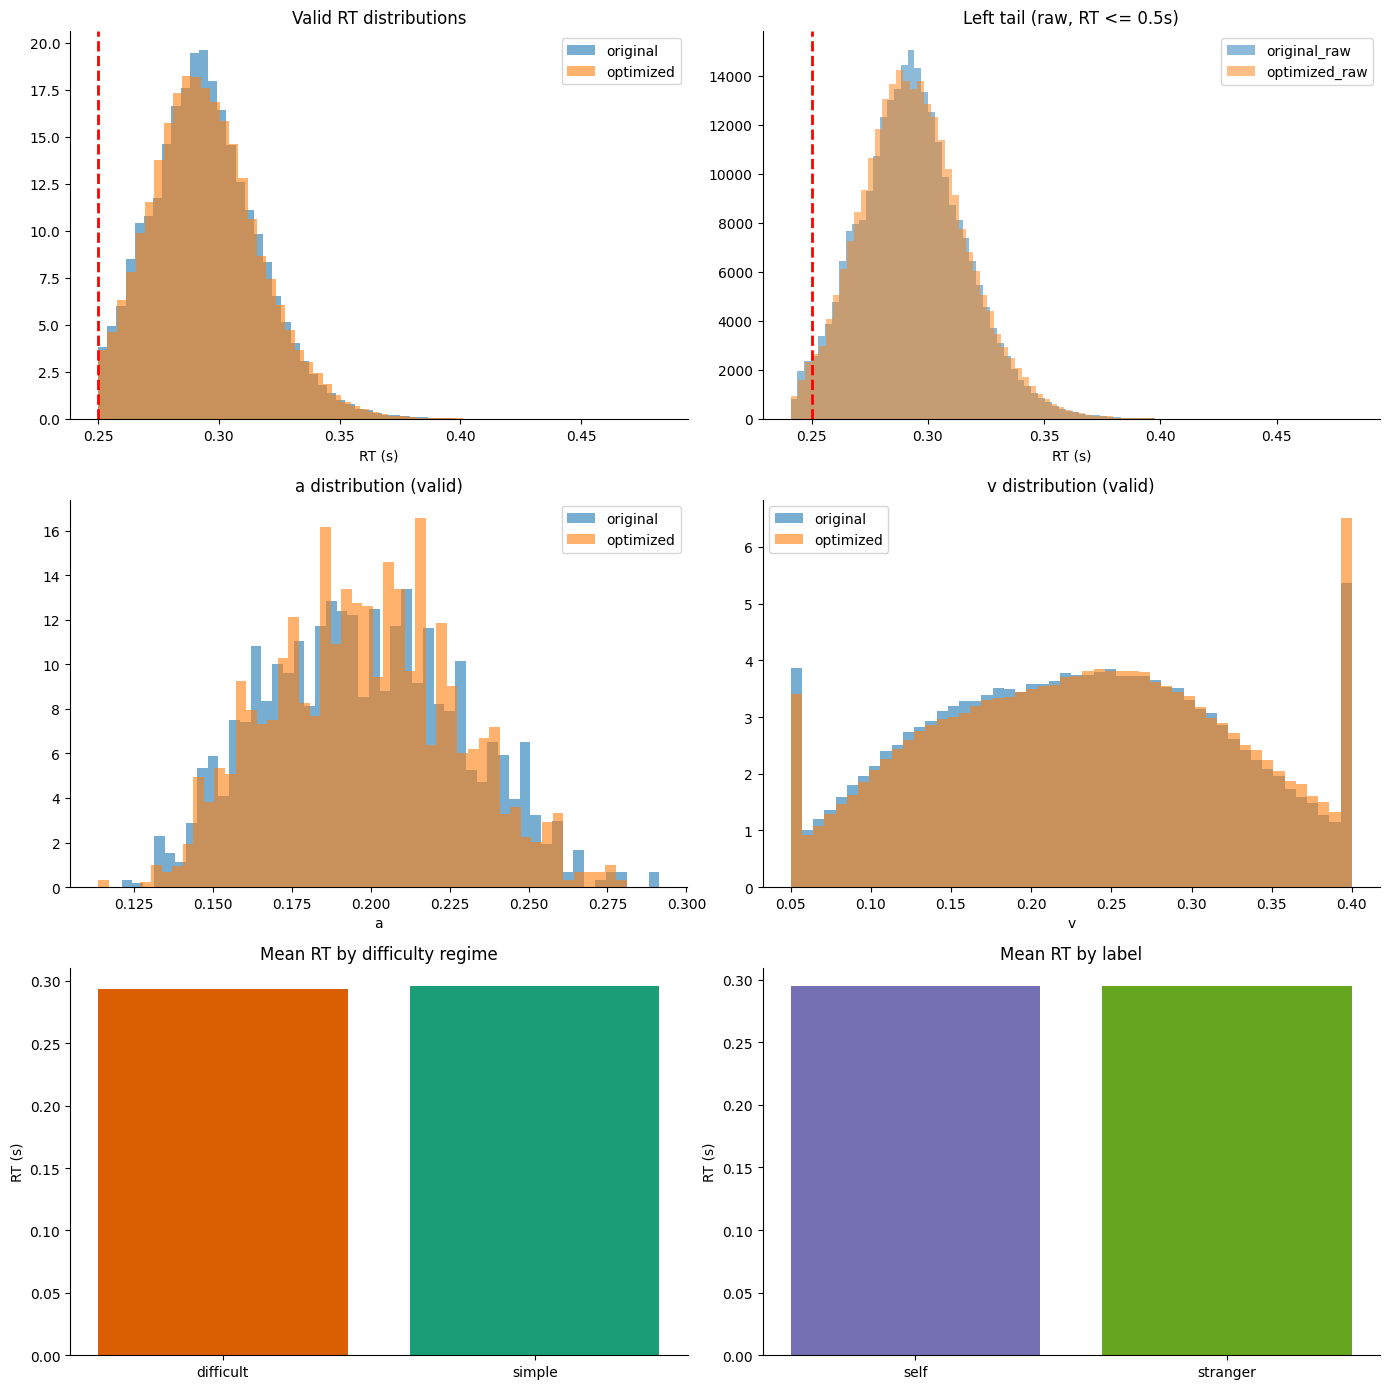

Saved plot to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\S2_gen_data_optimized_cp_v5\validation_overview_v5.png


In [11]:
if CONFIG['RUN_VALIDATION_PLOTS'] and 'df_original' in globals() and 'df_optimized' in globals():
    valid_original = extract_valid_trials(df_original)
    valid_optimized = extract_valid_trials(df_optimized)

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))

    axes[0, 0].hist(valid_original['RT'], bins=60, alpha=0.6, density=True, label='original')
    axes[0, 0].hist(valid_optimized['RT'], bins=60, alpha=0.6, density=True, label='optimized')
    axes[0, 0].axvline(CONFIG['MIN_VALID_RT'], color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title('Valid RT distributions')
    axes[0, 0].set_xlabel('RT (s)')
    axes[0, 0].legend()

    left_o = df_original[df_original['RT'] <= 0.5]
    left_p = df_optimized[df_optimized['RT'] <= 0.5]
    axes[0, 1].hist(left_o['RT'], bins=80, alpha=0.5, label='original_raw')
    axes[0, 1].hist(left_p['RT'], bins=80, alpha=0.5, label='optimized_raw')
    axes[0, 1].axvline(CONFIG['MIN_VALID_RT'], color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_title('Left tail (raw, RT <= 0.5s)')
    axes[0, 1].set_xlabel('RT (s)')
    axes[0, 1].legend()

    axes[1, 0].hist(valid_original['a'], bins=50, alpha=0.6, density=True, label='original')
    axes[1, 0].hist(valid_optimized['a'], bins=50, alpha=0.6, density=True, label='optimized')
    axes[1, 0].set_title('a distribution (valid)')
    axes[1, 0].set_xlabel('a')
    axes[1, 0].legend()

    axes[1, 1].hist(valid_original['v'], bins=50, alpha=0.6, density=True, label='original')
    axes[1, 1].hist(valid_optimized['v'], bins=50, alpha=0.6, density=True, label='optimized')
    axes[1, 1].set_title('v distribution (valid)')
    axes[1, 1].set_xlabel('v')
    axes[1, 1].legend()

    ease_summary = valid_optimized.groupby('difficulty_regime')['RT'].mean().reset_index()
    axes[2, 0].bar(ease_summary['difficulty_regime'], ease_summary['RT'], color=['#d95f02', '#1b9e77'])
    axes[2, 0].set_title('Mean RT by difficulty regime')
    axes[2, 0].set_ylabel('RT (s)')

    label_summary = valid_optimized.groupby('Label')['RT'].mean().reset_index()
    axes[2, 1].bar(label_summary['Label'], label_summary['RT'], color=['#7570b3', '#66a61e'])
    axes[2, 1].set_title('Mean RT by label')
    axes[2, 1].set_ylabel('RT (s)')

    plt.tight_layout()
    plot_path = FIG_DIR / 'validation_overview_v5.png'
    plt.savefig(plot_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved plot to:', plot_path)
else:
    print('Validation plots skipped.')

In [12]:
if CONFIG['RUN_LARGE_DATASET']:
    print(f"Generating large dataset: {CONFIG['NUM_SUBJECTS_LARGE']} subjects...")
    large_start = time.time()
    df_large = generate_data_random_params_optimized(
        CONFIG['NUM_SUBJECTS_LARGE'],
        CONFIG['NUM_TRIALS_LARGE'],
        batch_size=100,
        n_jobs=-1,
        cfg=CONFIG,
    )
    raw_path = DATA_DIR / 'v5_large_raw.csv'
    valid_path = DATA_DIR / 'v5_large_valid.csv'
    df_large.to_csv(raw_path, index=False)
    extract_valid_trials(df_large).to_csv(valid_path, index=False)
    print('Saved raw large dataset to:', raw_path)
    print('Saved valid large dataset to:', valid_path)
    print(f'Time: {time.time() - large_start:.2f}s')
else:
    print('Large dataset generation skipped (RUN_LARGE_DATASET=False).')

Large dataset generation skipped (RUN_LARGE_DATASET=False).


## Fast-RT diagnosis

This section diagnoses the raw optimized dataset first, because a filtered valid dataset may hide where the problem originates.

In [13]:
# ---------------------------------------------------------------------------
# Choose dataset to diagnose
# ---------------------------------------------------------------------------
if 'df_optimized' in globals():
    df_diag = df_optimized.copy()
    diag_name = 'df_optimized_raw'
elif 'df_original' in globals():
    df_diag = df_original.copy()
    diag_name = 'df_original_raw'
else:
    raise ValueError('Run the benchmark generation cells first so there is data to diagnose.')

print(f'Diagnosing dataset: {diag_name}')
print(f'Rows: {len(df_diag):,}')

FAST_RT_THRESHOLD = CONFIG['MIN_VALID_RT']
VERY_FAST_RT_THRESHOLD = 0.23

print()
print('=== Overall fast RT summary ===')
print(f'Fast RT threshold: {FAST_RT_THRESHOLD:.3f} s')
print(f'T0 mean target: {CONFIG["T0_MEAN"]:.3f} s')
print(f'Fast RT count: {(df_diag["RT"] < FAST_RT_THRESHOLD).sum():,}')
print(f'Fast RT proportion: {(df_diag["RT"] < FAST_RT_THRESHOLD).mean():.4%}')
print(f'Very fast RT (< {VERY_FAST_RT_THRESHOLD:.2f}s) proportion: {(df_diag["RT"] < VERY_FAST_RT_THRESHOLD).mean():.4%}')


Diagnosing dataset: df_optimized_raw
Rows: 260,000

=== Overall fast RT summary ===
Fast RT threshold: 0.250 s
T0 mean target: 0.280 s
Fast RT count: 4,622
Fast RT proportion: 1.7777%
Very fast RT (< 0.23s) proportion: 0.0000%


In [14]:
df_diag = df_diag.copy()
df_diag['decision_time'] = df_diag['RT'] - df_diag['t0']
df_diag['is_fast_rt'] = df_diag['RT'] < FAST_RT_THRESHOLD
df_diag['is_very_fast_rt'] = df_diag['RT'] < VERY_FAST_RT_THRESHOLD

label_summary = (
    df_diag.groupby('Label')
    .agg(
        n=('RT', 'size'),
        mean_rt=('RT', 'mean'),
        median_rt=('RT', 'median'),
        fast_rate=('is_fast_rt', 'mean'),
        very_fast_rate=('is_very_fast_rt', 'mean'),
        mean_v=('v', 'mean'),
        mean_a=('a', 'mean'),
        mean_t0=('t0', 'mean'),
    )
    .reset_index()
)
print()
print('=== Label summary ===')
print(label_summary)

risk_summary = (
    df_diag.groupby(['P', 'T', 'W'])
    .agg(
        n=('RT', 'size'),
        fast_rate=('is_fast_rt', 'mean'),
        mean_rt=('RT', 'mean'),
        mean_v=('v', 'mean'),
        mean_a=('a', 'mean'),
        mean_t0=('t0', 'mean'),
        ease_score=('ease_score', 'mean'),
    )
    .reset_index()
    .sort_values(['fast_rate', 'mean_rt'], ascending=[False, True])
)
print()
print('=== Top 15 risky PTW combinations ===')
print(risk_summary.head(15))



=== Label summary ===
      Label       n   mean_rt  median_rt  fast_rate  very_fast_rate    mean_v  \
0      self  130000  0.293955   0.292732   0.017492             0.0  0.288082   
1  stranger  130000  0.293893   0.292659   0.018062             0.0  0.162632   

     mean_a   mean_t0  
0  0.194767  0.280049  
1  0.194767  0.280049  

=== Top 15 risky PTW combinations ===
       P    T    W    n  fast_rate   mean_rt    mean_v    mean_a   mean_t0  \
217   34  164  336  260   0.692308  0.248985  0.134311  0.155871  0.240000   
611   91  343  461  260   0.619231  0.249604  0.214807  0.163820  0.240000   
213   33  494  958  260   0.615385  0.250542  0.235520  0.169329  0.240000   
15     2  124  391  260   0.584615  0.250692  0.119542  0.172763  0.240000   
570   86  206  520  260   0.573077  0.250562  0.186485  0.171617  0.240000   
600   90   21  574  260   0.542308  0.251485  0.149738  0.180428  0.240000   
753  112  117  363  260   0.530769  0.252604  0.177497  0.188124  0.240000  

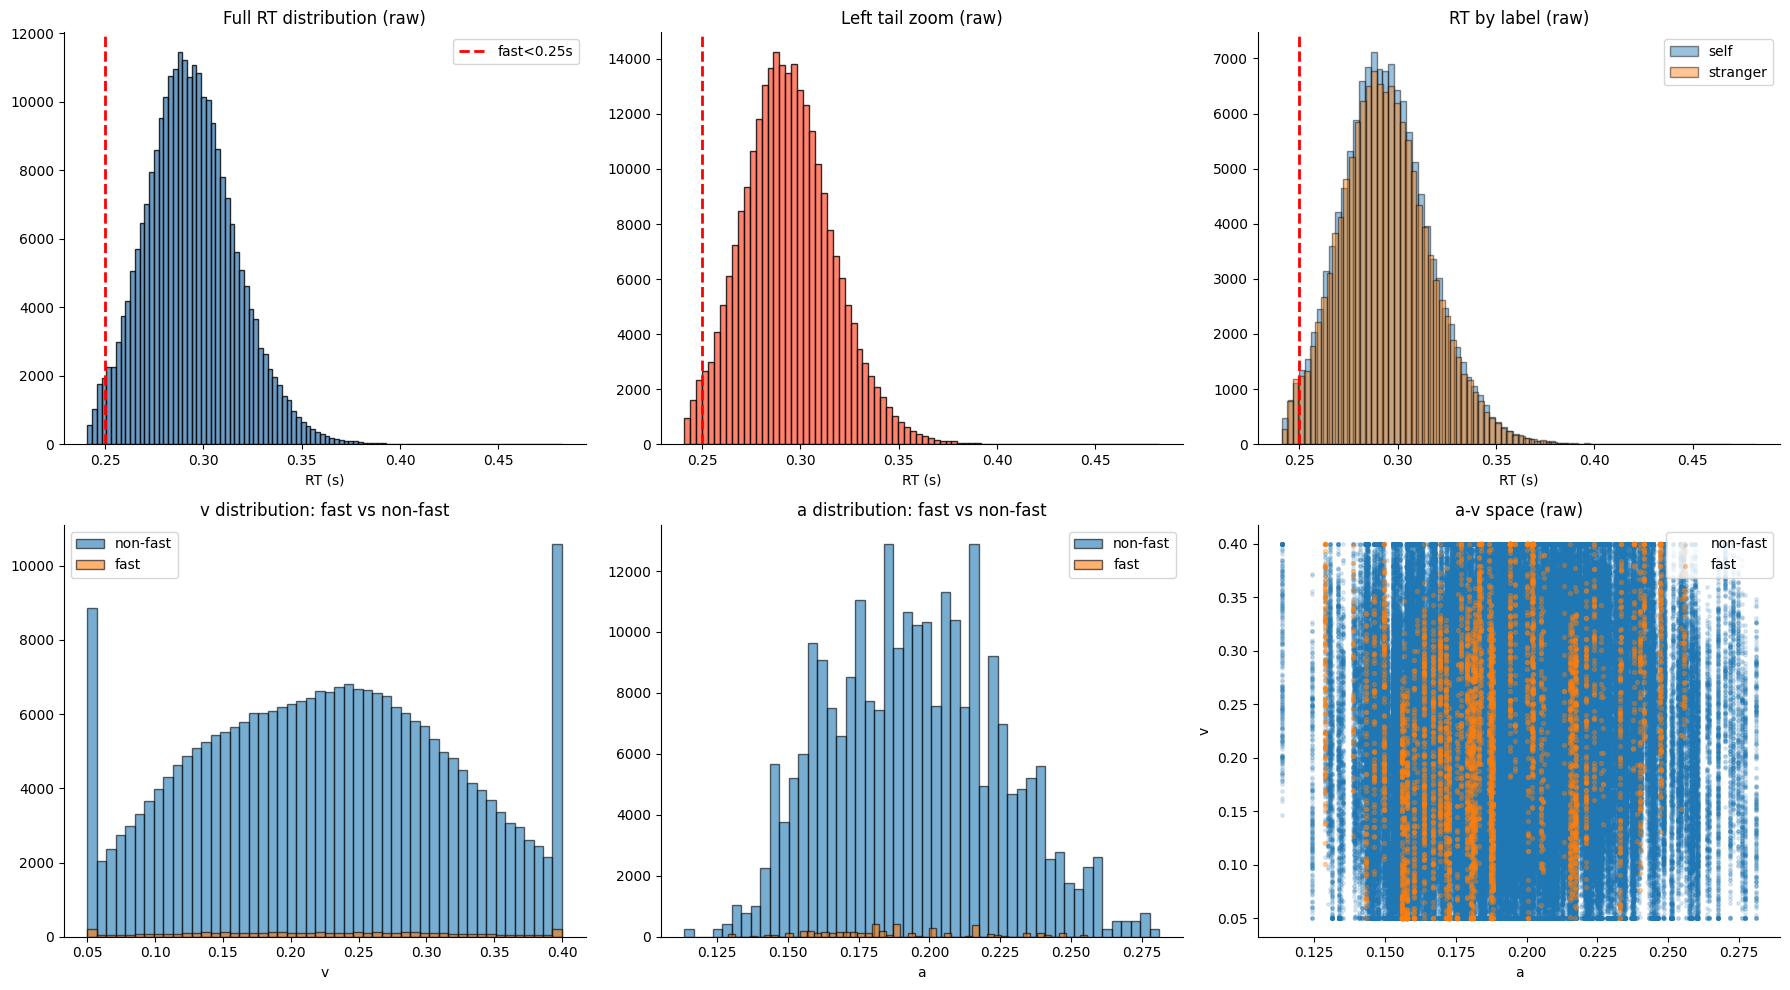

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(df_diag['RT'], bins=100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].axvline(FAST_RT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'fast<{FAST_RT_THRESHOLD:.2f}s')
axes[0, 0].set_title('Full RT distribution (raw)')
axes[0, 0].set_xlabel('RT (s)')
axes[0, 0].legend()

left_tail = df_diag[df_diag['RT'] <= 0.50]
axes[0, 1].hist(left_tail['RT'], bins=80, color='tomato', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(FAST_RT_THRESHOLD, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Left tail zoom (raw)')
axes[0, 1].set_xlabel('RT (s)')

for label in sorted(df_diag['Label'].dropna().unique()):
    subset = df_diag.loc[df_diag['Label'] == label, 'RT']
    axes[0, 2].hist(subset, bins=80, alpha=0.45, edgecolor='black', label=label)
axes[0, 2].axvline(FAST_RT_THRESHOLD, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_title('RT by label (raw)')
axes[0, 2].set_xlabel('RT (s)')
axes[0, 2].legend()

axes[1, 0].hist(df_diag.loc[~df_diag['is_fast_rt'], 'v'], bins=50, alpha=0.6, edgecolor='black', label='non-fast')
axes[1, 0].hist(df_diag.loc[df_diag['is_fast_rt'], 'v'], bins=50, alpha=0.6, edgecolor='black', label='fast')
axes[1, 0].set_title('v distribution: fast vs non-fast')
axes[1, 0].set_xlabel('v')
axes[1, 0].legend()

axes[1, 1].hist(df_diag.loc[~df_diag['is_fast_rt'], 'a'], bins=50, alpha=0.6, edgecolor='black', label='non-fast')
axes[1, 1].hist(df_diag.loc[df_diag['is_fast_rt'], 'a'], bins=50, alpha=0.6, edgecolor='black', label='fast')
axes[1, 1].set_title('a distribution: fast vs non-fast')
axes[1, 1].set_xlabel('a')
axes[1, 1].legend()

axes[1, 2].scatter(df_diag.loc[~df_diag['is_fast_rt'], 'a'], df_diag.loc[~df_diag['is_fast_rt'], 'v'], s=6, alpha=0.15, label='non-fast')
axes[1, 2].scatter(df_diag.loc[df_diag['is_fast_rt'], 'a'], df_diag.loc[df_diag['is_fast_rt'], 'v'], s=8, alpha=0.35, label='fast')
axes[1, 2].set_title('a-v space (raw)')
axes[1, 2].set_xlabel('a')
axes[1, 2].set_ylabel('v')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [17]:
valid_optimized = extract_valid_trials(df_optimized) if 'df_optimized' in globals() else None
if valid_optimized is not None:
    valid_path = DATA_DIR / 'benchmark_valid_optimized_v5.csv'
    raw_path = DATA_DIR / 'benchmark_raw_optimized_v5.csv'
    df_optimized.to_csv(raw_path, index=False)
    valid_optimized.to_csv(valid_path, index=False)
    print('Saved optimized raw benchmark to:', raw_path)
    print('Saved optimized valid benchmark to:', valid_path)

Saved optimized raw benchmark to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\S2_gen_data_optimized_cp_v5\benchmark_raw_optimized_v5.csv
Saved optimized valid benchmark to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\S2_gen_data_optimized_cp_v5\benchmark_valid_optimized_v5.csv


## How to interpret v5

### Current critical point

In this notebook, the current **difficulty critical point** is:

- `ease_score = 0.50`

Interpretation:

- `ease_score < 0.50` -> difficult regime -> target `v` in `0.05-0.20`
- `ease_score >= 0.50` -> simple regime -> target `v` in `0.20-0.40`

### If the next results still look wrong

- too many very fast RTs -> first adjust `t0` and/or `MIN_VALID_RT`
- RT too slow overall -> reduce `a`, reduce `t0`, or raise `v`
- self advantage too weak -> increase `SELF_V_BONUS`
- self advantage too strong -> reduce `SELF_V_BONUS`
- too many invalid trials in hard PTW regions -> increase `a` less aggressively or raise `v` slightly in difficult tasks

## What to look at after running v6

Please compare v6 against v5 on three dimensions:

1. whether self vs stranger mean RT separation returns
2. whether the fast-RT left tail stays controlled
3. whether the difficult vs simple regime still behaves sensibly

If self/stranger separation returns without reintroducing the left-tail problem, then the next step can be a PTW-dependent condition effect in v7.
